In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import torch
import cupy as cp
import mne
import sys
import os

sys.path.append("../..")
import act_var1 as act_cpu
import act_gpu_cuda as act_cupy
import act_gpu_pytorch as act_torch

In [ ]:
fs = 256
epoch_length = 256
order = 10
eeg_channels = ["HB_1"]
edf_path = os.path.join(os.getcwd(), '../Testing Scripts/Data/sub-1_task-Sleep_acq-headband_eeg.edf')
fc_info = (0.5, 15, 0.5)
logDt_info = (-4, 1, 0.5)
c_info = (-10, 10, 0.5)
tc_res = 256
tc_info = (0, tc_res, 32)

In [3]:
raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
raw.pick_channels(eeg_channels)
raw.notch_filter(freqs=50)
raw.filter(l_freq=0.1, h_freq=20.0, verbose=False)
data = raw.get_data().T

## Picking first epoch
segment_cpu = data[0:epoch_length, 0].astype(np.float32)
segments_cupy = cp.asarray(segment_cpu)
segments_torch = torch.tensor(segment_cpu, device="cuda")
t = np.arange(epoch_length) / fs

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 49.38
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 49.12 Hz)
- Upper passband edge: 50.62 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 50.88 Hz)
- Filter length: 1691 samples (6.605 s)



In [4]:
act_objs = {
    "CPU": act_cpu.ACT(FS=fs, length=epoch_length, tc_info=tc_info,
                       fc_info=fc_info, logDt_info=logDt_info, c_info=c_info,
                       force_regenerate=True, mute=True),
    "CuPy GPU": act_cupy.ACT(FS=fs, length=epoch_length, tc_info=tc_info,
                              fc_info=fc_info, logDt_info=logDt_info, c_info=c_info,
                              hybrid=False, force_regenerate=True, mute=True),
    "CuPy Hybrid": act_cupy.ACT(FS=fs, length=epoch_length, tc_info=tc_info,
                                 fc_info=fc_info, logDt_info=logDt_info, c_info=c_info,
                                 hybrid=True, force_regenerate=True, mute=True),
    "Torch GPU": act_torch.ACT(FS=fs, length=epoch_length, tc_info=tc_info,
                                fc_info=fc_info, logDt_info=logDt_info, c_info=c_info,
                                mode="gpu", force_regenerate=True, mute=True),
    "Torch Hybrid": act_torch.ACT(FS=fs, length=epoch_length, tc_info=tc_info,
                                   fc_info=fc_info, logDt_info=logDt_info, c_info=c_info,
                                   mode="hybrid", force_regenerate=True, mute=True)
}

Dictionary length: 92800
CPU cores: 32
GPU Devices detected: 1
Hybrid mode: False
Unified memory: False
Dictionary length: 92800
Generating dictionary on GPU...
Dictionary Generated.
CPU cores: 32
GPU Devices detected: 1
Hybrid mode: True
Unified memory: False
Dictionary length: 92800
Generating dictionary on CPU...
Dictionary Generated.
[DICT] Dictionary generated on GPU
[DICT] Dictionary generated on CPU


In [5]:
approximations = {}
for key, act_model in act_objs.items():
    if "CPU" in key:
        out = act_model.transform(segment_cpu, order=order)["approx"]
    elif "CuPy" in key:
        out = act_model.transform(segments_cupy, order=order)["approx"]
        if isinstance(out, cp.ndarray):
            out = out.get()
    else:  # Torch
        out = act_model.transform(segments_torch, order=order)["approx"]
        if torch.is_tensor(out):
            out = out.cpu().numpy()
    approximations[key] = np.asarray(out).squeeze()

In [6]:
COLORS = {
    "CPU":          "#e63946",
    "CuPy GPU":     "#2a9d8f",
    "CuPy Hybrid":  "#f4a261",
    "Torch GPU":    "#457b9d",
    "Torch Hybrid": "#6a4c93",
}

In [7]:
print("=== Approximation Shapes & Ranges ===")
first = list(approximations.values())[0]
for key, arr in approximations.items():
    print(
        f"{key:15s} | shape={str(arr.shape):10s} | "
        f"min={arr.min():10.6f} | max={arr.max():10.6f} | "
        f"max_diff_from_first={np.max(np.abs(arr - first)):.2e}"
    )

=== Approximation Shapes & Ranges ===
CPU             | shape=(256,)     | min= -0.000002 | max=  0.000067 | max_diff_from_first=0.00e+00
CuPy GPU        | shape=(256,)     | min= -0.000002 | max=  0.000067 | max_diff_from_first=1.82e-11
CuPy Hybrid     | shape=(256,)     | min= -0.000002 | max=  0.000067 | max_diff_from_first=1.82e-11
Torch GPU       | shape=(256,)     | min= -0.000002 | max=  0.000067 | max_diff_from_first=1.82e-11
Torch Hybrid    | shape=(256,)     | min= -0.000002 | max=  0.000067 | max_diff_from_first=7.28e-12


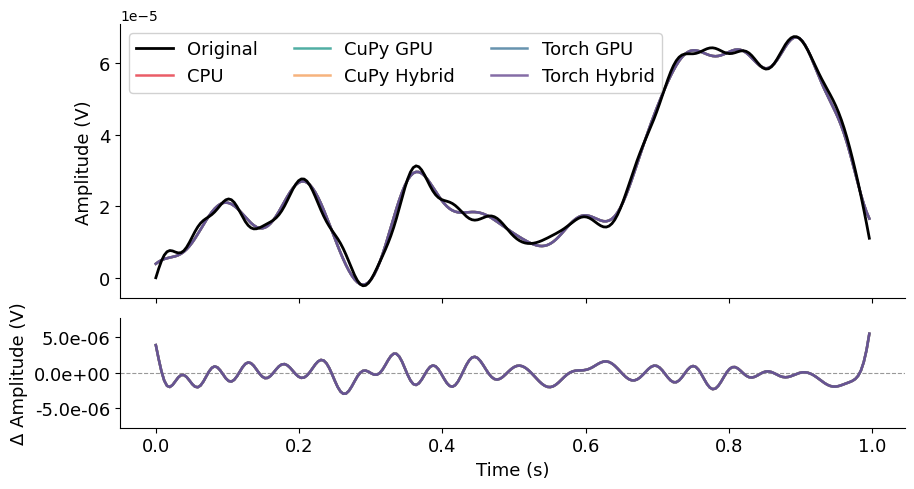

Plot saved to act_comparison_validation.pdf


In [8]:
fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, figsize=(9.25, 5),
    gridspec_kw={"height_ratios": [3, 1.2]},
    sharex=True
)
fig.patch.set_facecolor("white")

# ---- TOP: overlaid signal + approximations ----
ax_top.set_facecolor("white")
# Original — thick black on top
ax_top.plot(t, segment_cpu, color="black", linewidth=2.0,
            label="Original", zorder=10)
# Approximations — coloured, slightly thinner, slightly transparent
for key, arr in approximations.items():
    ax_top.plot(t, arr, color=COLORS[key], linewidth=1.8,
                alpha=0.82, label=key, zorder=5)

ax_top.set_ylabel("Amplitude (V)", fontsize=13)
ax_top.tick_params(axis="both", labelsize=13)
ax_top.spines["top"].set_visible(False)
ax_top.spines["right"].set_visible(False)

legend = ax_top.legend(
    loc="upper left", fontsize=13,
    framealpha=0.9, edgecolor="#cccccc",
    ncol=3
)

# ---- BOTTOM: residual difference from original ----
ax_bot.set_facecolor("white")
ax_bot.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.4)

for key, arr in approximations.items():
    diff = arr - segment_cpu
    ax_bot.plot(t, diff, color=COLORS[key], linewidth=1.8, alpha=0.85, label=key)

ax_bot.set_ylabel("Δ Amplitude (V)", fontsize=13)
ax_bot.set_xlabel("Time (s)", fontsize=13)
ax_bot.tick_params(axis="both", labelsize=13)
ax_bot.spines["top"].set_visible(False)
ax_bot.spines["right"].set_visible(False)

diff_max = max(np.max(np.abs(arr - segment_cpu)) for arr in approximations.values())
pad = diff_max * 1.4 if diff_max > 0 else 1e-6
ax_bot.set_ylim(-pad, pad)
ax_bot.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.1e"))

plt.tight_layout()
plt.savefig("act_comparison_validation.pdf", bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()
print("Plot saved to act_comparison_validation.pdf")